In [1]:
import Pkg
Pkg.activate("..")
Pkg.status()

  Activating project at `~/quantum_computing/quantum_stochastic_programming`


Status `~/quantum_computing/quantum_stochastic_programming/Project.toml`
  [07493b3f] Alpine v0.5.8
  [336ed68f] CSV v0.10.16
  [a93c6f00] DataFrames v1.8.2
  [bb8be931] EAGO v0.9.2
  [87dc4568] HiGHS v1.23.0
  [b6b21f68] Ipopt v1.15.0
  [4076af6c] JuMP v1.30.1
  [2ddba703] Juniper v0.9.4
  [19f71287] MAiNGO v0.2.2
  [82193955] SCIP v0.12.8


In [2]:
import DataFrames as DF
import LinearAlgebra as LA

import CSV

using Plots

In [3]:

_dir = @__DIR__

# Classical JuMP/Juniper sweep (demand 1:0.1:12)
df_jump = CSV.read(joinpath(_dir, "poster_example_jump_results.csv"), DF.DataFrame)

# # Classical second-stage surface vs x for d=8
# df_surf = CSV.read(joinpath(_dir, "objective_surface_d8.csv"), DF.DataFrame)

# Quantum DQA sweep (interp modes × demand levels × opt methods)
df_quantum = CSV.read(joinpath(_dir, "simple_ed_cuda_q_sweep.csv"), DF.DataFrame)
df_quantum 

display(df_jump)
# display(df_surf)
display(df_quantum)


Row,demand,status,obj,first_stage,second_stage,max_violation,n_fractional,xsol
,Float64,String15,Float64,Float64,Float64,Float64,Int64,Float64
1,1.0,LOCALLY_SOLVED,2.7301,3.76078e-8,2.7301,9.77974e-8,0,0.0
2,2.0,LOCALLY_SOLVED,6.7301,4.0,2.7301,9.80268e-8,0,1.0
3,3.0,LOCALLY_SOLVED,10.7301,8.0,2.7301,9.80292e-8,0,2.0
4,4.0,LOCALLY_SOLVED,14.7301,12.0,2.7301,9.80297e-8,0,3.0
5,5.0,LOCALLY_SOLVED,18.7301,16.0,2.7301,9.803e-8,0,4.0
6,6.0,LOCALLY_SOLVED,22.7301,20.0,2.7301,9.80302e-8,0,5.0
7,7.0,LOCALLY_SOLVED,26.7301,24.0,2.7301,9.80303e-8,0,6.0
8,8.0,LOCALLY_SOLVED,30.7301,28.0,2.7301,9.80304e-8,0,7.0
9,9.0,LOCALLY_SOLVED,34.7301,32.0,2.7301,9.80305e-8,0,8.0


Row,interp_mode,d,method,x_star,wd_star,fs_obj,ss_obj,obj_star,nfev,nit,time_ms,success
,String7,Float64,String15,Float64,Float64,Float64,Float64,Float64,Int64,Int64?,Float64,Bool
1,linear,1.0,bounded,5.36345e-7,0.999999,2.14538e-6,2.85599,2.85599,30,missing,0.147833,true
2,linear,1.0,COBYLA,0.0,1.0,0.0,2.85599,2.85599,7,missing,6.91783,true
3,linear,1.0,Nelder-Mead,0.0,1.0,0.0,2.85599,2.85599,63,23,0.52275,true
4,linear,1.0,L-BFGS-B,0.0,1.0,0.0,2.85599,2.85599,42,1,0.643917,false
5,linear,1.0,BFGS,0.0,1.0,0.0,2.85599,2.85599,62,1,1.93421,false
6,linear,1.5,bounded,0.5,1.0,2.0,2.85599,4.85599,21,missing,0.101416,true
7,linear,1.5,COBYLA,0.5,1.0,2.0,2.85599,4.85599,20,missing,7.03975,true
8,linear,1.5,Nelder-Mead,0.5,1.0,2.0,2.85599,4.85599,52,26,0.528958,true
9,linear,1.5,L-BFGS-B,0.5,1.0,2.0,2.85599,4.85599,62,9,1.13512,true


In [4]:
# ── Filter to selected (interp_mode, method) combinations ────────────────────
_keep = Set([
    ("linear",  "Nelder-Mead"),
    ("linear",  "COBYLA"),
    ("hermite", "L-BFGS-B"),
    ("hermite", "BFGS"),
])
df_quantum_filt = filter(r -> (r.interp_mode, r.method) in _keep, df_quantum)

# ── Join quantum results with classical reference on demand level ──────────────
# df_jump uses integer demands; df_quantum has 0.5-spaced demands.
# Only rows whose `d` exactly matches a `demand` in df_jump get a reference.
df_ref = DF.rename(df_jump, :demand => :d, :obj => :obj_ref, :xsol => :x_ref)
df_ref = df_ref[:, [:d, :obj_ref, :x_ref]]

df = DF.innerjoin(df_quantum_filt, df_ref; on = :d)

# ── Error metrics ──────────────────────────────────────────────────────────────
# Relative objective error:  (obj_star − obj_ref) / |obj_ref|
# Absolute x* error:         x_star − x_ref
ε = 1e-6
df[!, :rel_obj_err] = (df.obj_star .- df.obj_ref) ./ abs.(df.obj_ref)
df[!, :abs_x_err]   = df.x_star .- df.x_ref

display(df[:, [:interp_mode, :d, :method, :x_star, :x_ref, :abs_x_err, :obj_star, :obj_ref, :rel_obj_err]])

Row,interp_mode,d,method,x_star,x_ref,abs_x_err,obj_star,obj_ref,rel_obj_err
,String7,Float64,String15,Float64,Float64,Float64,Float64,Float64,Float64
1,linear,1.0,COBYLA,0.0,0.0,0.0,2.85599,2.7301,0.0461093
2,linear,1.0,Nelder-Mead,0.0,0.0,0.0,2.85599,2.7301,0.0461093
3,linear,2.0,COBYLA,1.0,1.0,0.0,6.85599,6.7301,0.0187045
4,linear,2.0,Nelder-Mead,1.0,1.0,0.0,6.85599,6.7301,0.0187045
5,linear,3.0,COBYLA,2.0,2.0,0.0,10.856,10.7301,0.0117318
6,linear,3.0,Nelder-Mead,2.0,2.0,5.96047e-9,10.856,10.7301,0.0117318
7,linear,4.0,COBYLA,3.0,3.0,0.0,14.856,14.7301,0.00854598
8,linear,4.0,Nelder-Mead,3.0,3.0,2.66454e-15,14.856,14.7301,0.00854598
9,linear,5.0,COBYLA,4.0,4.0,0.0,18.856,18.7301,0.0067209


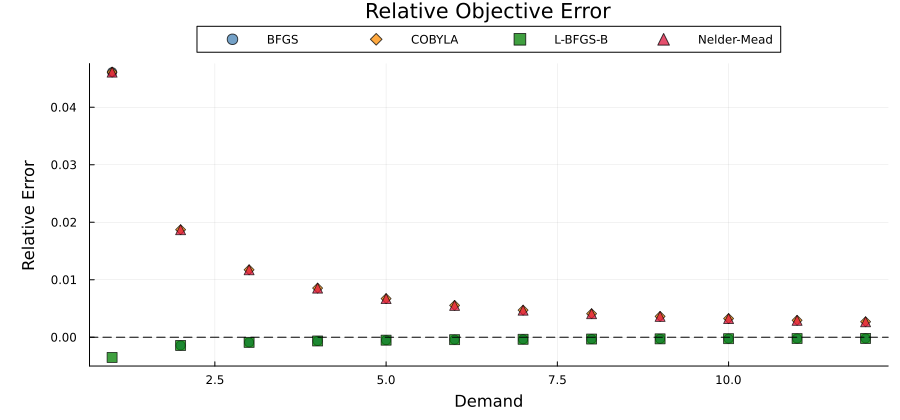

"/Users/jmaack/quantum_computing/quantum_stochastic_programming/siam_poster_example/poster_rel_obj_err.png"

In [5]:
# ── Relative objective error by method and interpolation mode ─────────────────
methods      = sort(unique(df.method))
interp_modes = sort(unique(df.interp_mode))
method_markers = [:circle, :diamond, :square, :utriangle, :dtriangle]
method_colors  = [:steelblue, :darkorange, :green, :crimson]

p_obj = plot(
    # title  = "Relative objective error  (quantum − classical) / |classical|",
    title  = "Relative Objective Error",
    xlabel = "Demand",
    ylabel = "Relative Error",
    legend         = :outertop,
    legendcolumns  = 4,
    size           = (900, 420),
    left_margin    = 8Plots.mm,
    bottom_margin  = 5Plots.mm,
)

for (mi, meth) in enumerate(methods)
    sub = filter(r -> r.method == meth, df)
    isempty(sub) && continue
    scatter!(p_obj, sub.d, sub.rel_obj_err;
        label  = meth,
        color  = method_colors[mi],
        marker = method_markers[mi],
        alpha  = 0.75,
        ms     = 5,
    )
end
hline!(p_obj, [0.0]; color = :black, linestyle = :dash, label = "", lw = 1)

display(p_obj)
savefig(p_obj, joinpath(_dir, "poster_rel_obj_err.png"))

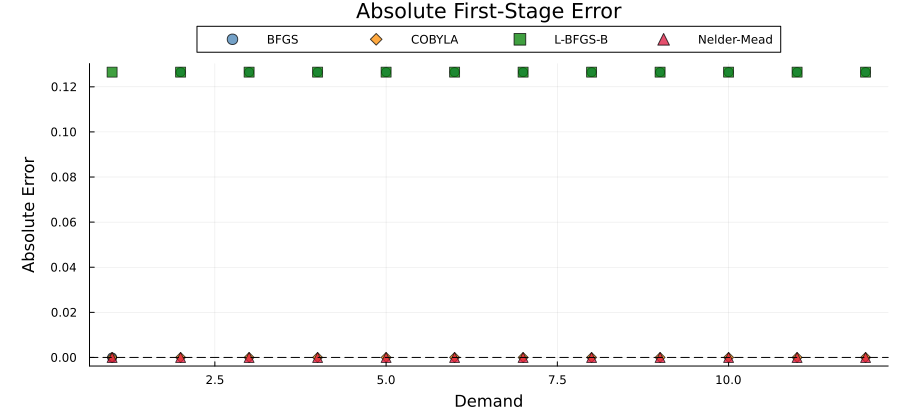

"/Users/jmaack/quantum_computing/quantum_stochastic_programming/siam_poster_example/poster_abs_x_err.png"

In [6]:
# ── Absolute first-stage solution error by method and interpolation mode ───────
p_x = plot(
    title         = "Absolute First-Stage Error",
    xlabel        = "Demand",
    ylabel        = "Absolute Error",
    legend        = :outertop,
    legendcolumns = 4,
    size          = (900, 420),
    left_margin   = 8Plots.mm,
    bottom_margin = 5Plots.mm,
)

for (mi, meth) in enumerate(methods)
    sub = filter(r -> r.method == meth, df)
    isempty(sub) && continue
    scatter!(p_x, sub.d, sub.abs_x_err;
        label  = meth,
        color  = method_colors[mi],
        marker = method_markers[mi],
        alpha  = 0.75,
        ms     = 5,
    )
end
hline!(p_x, [0.0]; color = :black, linestyle = :dash, label = "", lw = 1)

display(p_x)
savefig(p_x, joinpath(_dir, "poster_abs_x_err.png"))

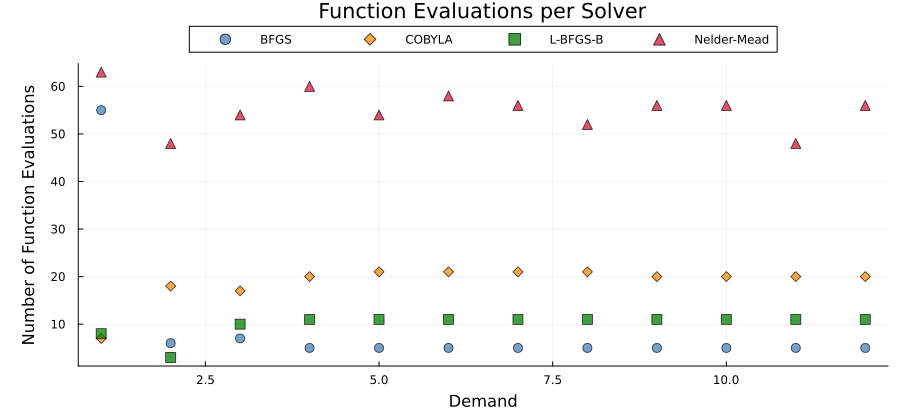

"/Users/jmaack/quantum_computing/quantum_stochastic_programming/siam_poster_example/poster_nfev.png"

In [7]:
# ── Function evaluations per solver vs demand ─────────────────────────────────
# nit is missing for 'bounded' and 'COBYLA'; nfev is always populated.
p_nfev = plot(
    title  = "Function Evaluations per Solver",
    xlabel = "Demand",
    ylabel = "Number of Function Evaluations",
    legend        = :outertop,
    legendcolumns = 4,
    size          = (900, 420),
    left_margin   = 8Plots.mm,
    bottom_margin = 5Plots.mm,
)

for (mi, meth) in enumerate(methods)
    sub = filter(r -> r.method == meth, df)
    isempty(sub) && continue
    scatter!(p_nfev, sub.d, sub.nfev;
        label  = meth,
        color  = method_colors[mi],
        marker = method_markers[mi],
        alpha  = 0.75,
        ms     = 5,
    )
end

display(p_nfev)
savefig(p_nfev, joinpath(_dir, "poster_nfev.png"))

In [8]:
idx = (df[:,:method] .== "L-BFGS-B")
df[idx,:]

Row,interp_mode,d,method,x_star,wd_star,fs_obj,ss_obj,obj_star,nfev,nit,time_ms,success,obj_ref,x_ref,rel_obj_err,abs_x_err
,String7,Float64,String15,Float64,Float64,Float64,Float64,Float64,Int64,Int64?,Float64,Bool,Float64,Float64,Float64,Float64
1,hermite,1.0,L-BFGS-B,0.126505,0.873495,0.506018,2.21449,2.72051,8,7,0.479042,true,2.7301,0.0,-0.00351355,0.126505
2,hermite,2.0,L-BFGS-B,1.1265,0.873495,4.50602,2.21449,6.72051,3,1,0.142708,true,6.7301,1.0,-0.00142529,0.126505
3,hermite,3.0,L-BFGS-B,2.1265,0.873495,8.50602,2.21449,10.7205,10,5,0.362667,true,10.7301,2.0,-0.000893966,0.126505
4,hermite,4.0,L-BFGS-B,3.1265,0.873495,12.506,2.21449,14.7205,11,4,0.390459,true,14.7301,3.0,-0.000651207,0.126505
5,hermite,5.0,L-BFGS-B,4.1265,0.873495,16.506,2.21449,18.7205,11,4,0.381333,true,18.7301,4.0,-0.000512135,0.126505
6,hermite,6.0,L-BFGS-B,5.1265,0.873495,20.506,2.21449,22.7205,11,4,0.371917,true,22.7301,5.0,-0.000422011,0.126505
7,hermite,7.0,L-BFGS-B,6.1265,0.873495,24.506,2.21449,26.7205,11,4,0.471458,true,26.7301,6.0,-0.000358859,0.126505
8,hermite,8.0,L-BFGS-B,7.1265,0.873495,28.506,2.21449,30.7205,11,4,0.400625,true,30.7301,7.0,-0.000312148,0.126505
9,hermite,9.0,L-BFGS-B,8.1265,0.873495,32.506,2.21449,34.7205,11,4,0.405834,true,34.7301,8.0,-0.000276197,0.126505


In [9]:
idx = df[:,:d] .== 1.0
df[idx,:]

Row,interp_mode,d,method,x_star,wd_star,fs_obj,ss_obj,obj_star,nfev,nit,time_ms,success,obj_ref,x_ref,rel_obj_err,abs_x_err
,String7,Float64,String15,Float64,Float64,Float64,Float64,Float64,Int64,Int64?,Float64,Bool,Float64,Float64,Float64,Float64
1,linear,1.0,COBYLA,0.0,1.0,0.0,2.85599,2.85599,7,missing,6.91783,true,2.7301,0.0,0.0461093,0.0
2,linear,1.0,Nelder-Mead,0.0,1.0,0.0,2.85599,2.85599,63,23,0.52275,true,2.7301,0.0,0.0461093,0.0
3,hermite,1.0,L-BFGS-B,0.126505,0.873495,0.506018,2.21449,2.72051,8,7,0.479042,true,2.7301,0.0,-0.00351355,0.126505
4,hermite,1.0,BFGS,0.0,1.0,0.0,2.85599,2.85599,55,1,1.618,false,2.7301,0.0,0.0461093,0.0
